# Classificação: sistema de apoio à decisão p/ aprovação de crédito
Romain Sebire - 125 009 460

## Importação das bibliotecas e dos dados

Nesta célula, estamos importando as bibliotecas essenciais para análise de dados, visualização, pré-processamento, treinamento e avaliação de modelos de machine learning.

In [3]:
# --- Importações iniciais ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [4]:
# --- Carregamento dos dados ---
train_df = pd.read_csv('data/conjunto_de_treinamento.csv')
test_df = pd.read_csv('data/conjunto_de_teste.csv')
sample_submission = pd.read_csv('data/exemplo_arquivo_respostas.csv')

print("Dimensões do conjunto de treinamento:", train_df.shape)
print("Dimensões do conjunto de teste:", test_df.shape)

Dimensões do conjunto de treinamento: (20000, 42)
Dimensões do conjunto de teste: (5000, 41)


Os dados foram importados corretamente: há 20.000 linhas no conjunto de treinamento e 5.000 linhas no conjunto de teste.  
Há 42 colunas de dados no conjunto de treinamento e apenas 41 no conjunto de teste, pois a coluna de resposta está ausente.

## Análise Exploratória de Dados

### Exibição das features e contagem dos valores ausentes

In [18]:
# Para visualizar todas as colunas
pd.set_option('display.max_columns', None)

# Exibição das primeiras linhas
df = train_df.copy()
df.head()

,id_solicitante,produto_solicitado,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,nacionalidade,estado_onde_nasceu,estado_onde_reside,possui_telefone_residencial,codigo_area_telefone_residencial,tipo_residencia,meses_na_residencia,possui_telefone_celular,possui_email,renda_mensal_regular,renda_extra,possui_cartao_visa,possui_cartao_mastercard,possui_cartao_diners,possui_cartao_amex,possui_outros_cartoes,qtde_contas_bancarias,qtde_contas_bancarias_especiais,valor_patrimonio_pessoal,possui_carro,vinculo_formal_com_empresa,estado_onde_trabalha,possui_telefone_trabalho,codigo_area_telefone_trabalho,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha,inadimplente
0,1,1,10,presencial,1,M,85,2,0,0,1,CE,CE,Y,107,1.0,12.0,N,0,480.0,0.0,0,0,0,0,0,1,1,0.0,1,N,,N,,0,9.0,1.0,0.0,0.0,600.0,600.0,0
1,2,1,25,internet,1,F,38,1,0,0,1,SE,SE,Y,91,1.0,5.0,N,1,380.0,0.0,0,0,0,0,0,0,0,0.0,0,N,,N,,0,2.0,5.0,NaN,NaN,492.0,492.0,0
2,3,1,20,internet,1,F,37,2,0,0,1,BA,BA,Y,90,5.0,1.0,N,1,600.0,0.0,0,0,0,0,0,0,0,0.0,0,N,,N,,0,NaN,NaN,NaN,NaN,450.0,450.0,1
3,4,1,20,internet,1,M,37,1,1,0,1,RS,RS,Y,54,1.0,1.0,N,1,460.0,0.0,0,0,0,0,0,0,0,0.0,0,Y,RS,Y,54,0,9.0,2.0,NaN,NaN,932.0,932.0,1
4,5,7,1,internet,1,F,51,1,3,0,1,BA,BA,Y,86,0.0,1.0,N,1,687.0,600.0,0,0,0,0,0,0,0,0.0,1,Y,BA,N,,0,9.0,5.0,NaN,NaN,440.0,440.0,1


In [23]:
# Exibição da lista de features e seus tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_solicitante                    20000 non-null  int64  
 1   produto_solicitado                20000 non-null  int64  
 2   dia_vencimento                    20000 non-null  int64  
 3   forma_envio_solicitacao           20000 non-null  object 
 4   tipo_endereco                     20000 non-null  int64  
 5   sexo                              20000 non-null  object 
 6   idade                             20000 non-null  int64  
 7   estado_civil                      20000 non-null  int64  
 8   qtde_dependentes                  20000 non-null  int64  
 9   grau_instrucao                    20000 non-null  int64  
 10  nacionalidade                     20000 non-null  int64  
 11  estado_onde_nasceu                20000 non-null  object 
 12  esta

In [24]:
# Exibição da distribuição da variável alvo
df['inadimplente'].value_counts(normalize=True)

inadimplente
0    0.5
1    0.5
Name: proportion, dtype: float64

A variável alvo está perfeitamente distribuída: 50% são bons pagadores e 50% inadimplentes.

In [5]:
# Exibição das features com valores ausentes (train_df)
missing = train_df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

grau_instrucao_companheiro    12860
profissao_companheiro         11514
profissao                      3097
ocupacao                       2978
meses_na_residencia            1450
tipo_residencia                 536
dtype: int64

In [6]:
# Exibição das features com valores ausentes (test_df)
missing = test_df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

grau_instrucao_companheiro    3210
profissao_companheiro         2887
profissao                      762
ocupacao                       690
meses_na_residencia            362
tipo_residencia                125
dtype: int64

Apenas 6 features das 42 têm valores ausentes, profissao_companheiro e grau_instrucao_companheiro têm mais da metade das linhas com valores ausentes. Será necessário preencher esses valores ausentes com um método adequado.

### Plotagem das distribuições de cada feature

Vamos analisar a distribuição de cada feature. Isso permite explorar visualmente a repartição dos dados em cada feature, sendo útil para entender sua estrutura, detectar desequilíbrios ou anomalias e orientar as escolhas no tratamento dos dados.


Distribuição de 'produto_solicitado' (valores ausentes: 0)


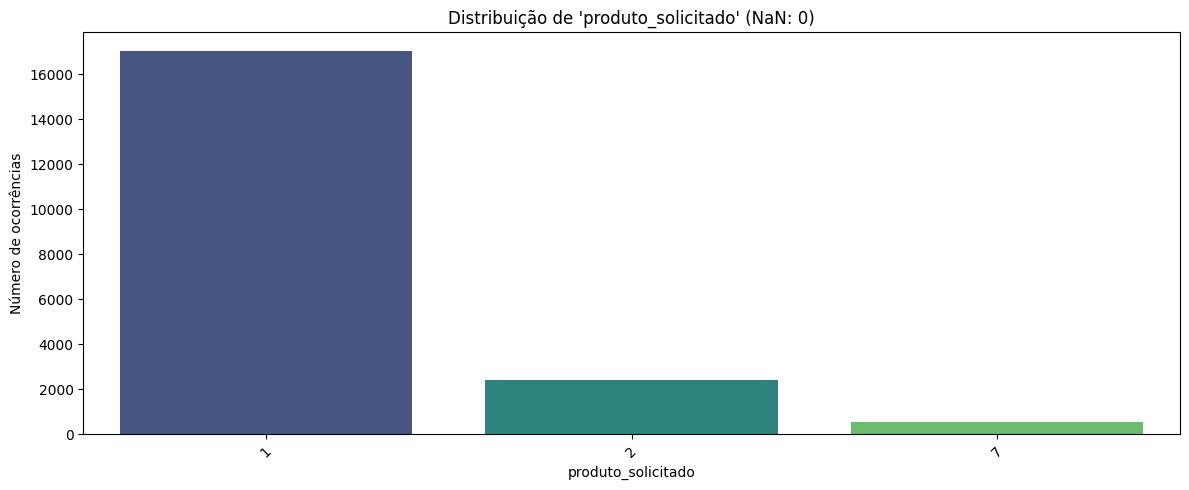


Distribuição de 'dia_vencimento' (valores ausentes: 0)


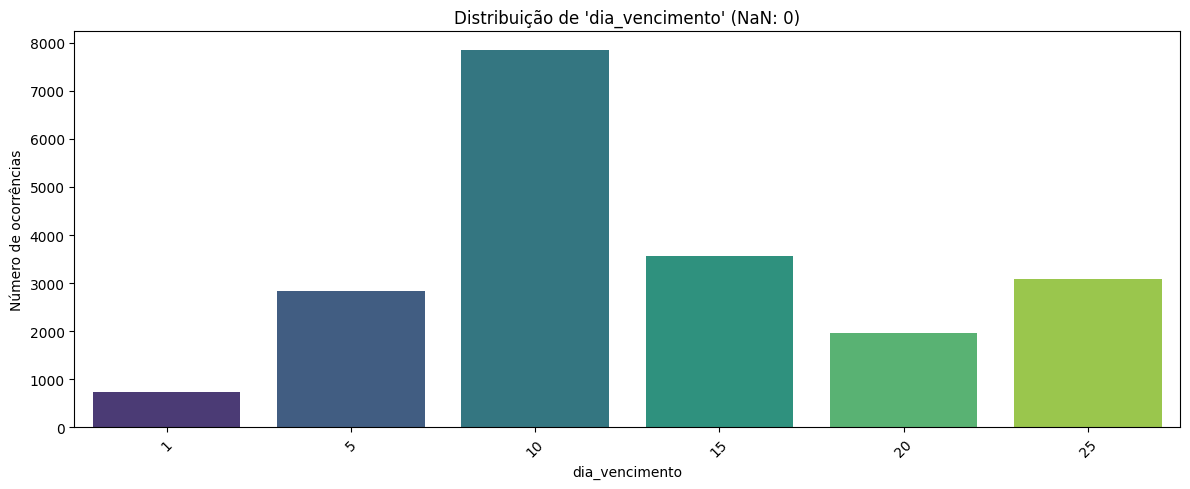


Distribuição de 'forma_envio_solicitacao' (valores ausentes: 0)


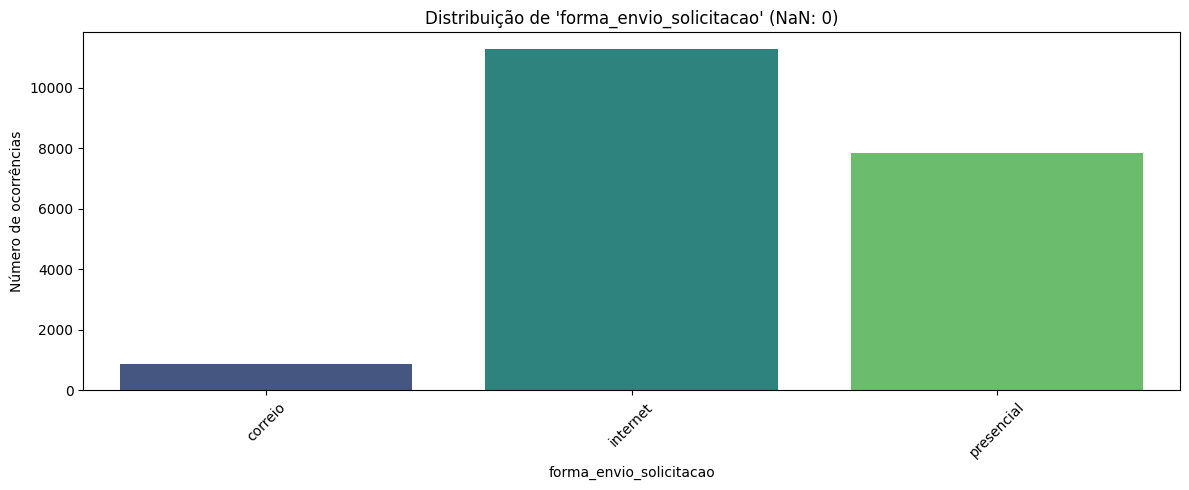


Distribuição de 'tipo_endereco' (valores ausentes: 0)


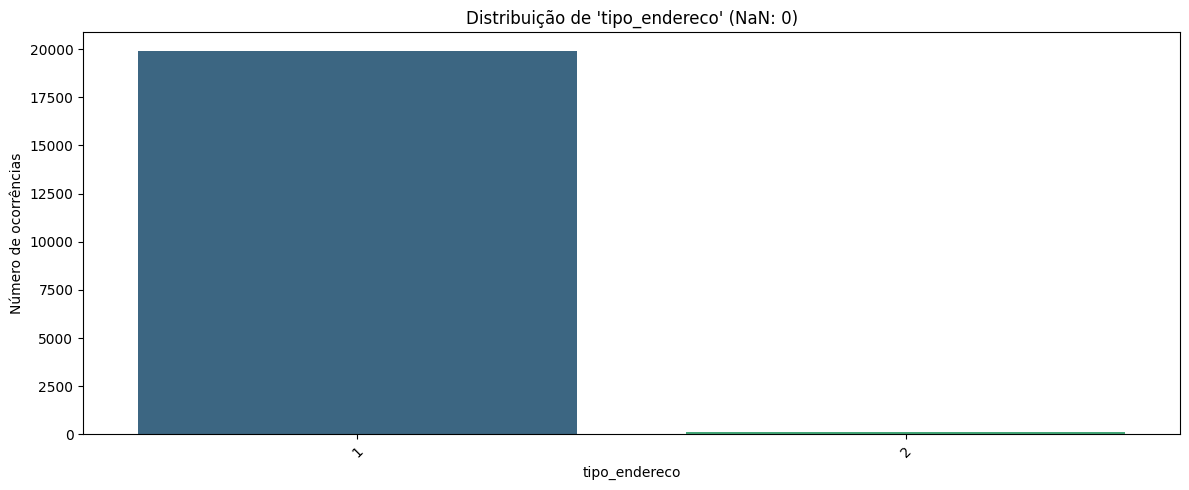


Distribuição de 'sexo' (valores ausentes: 0)


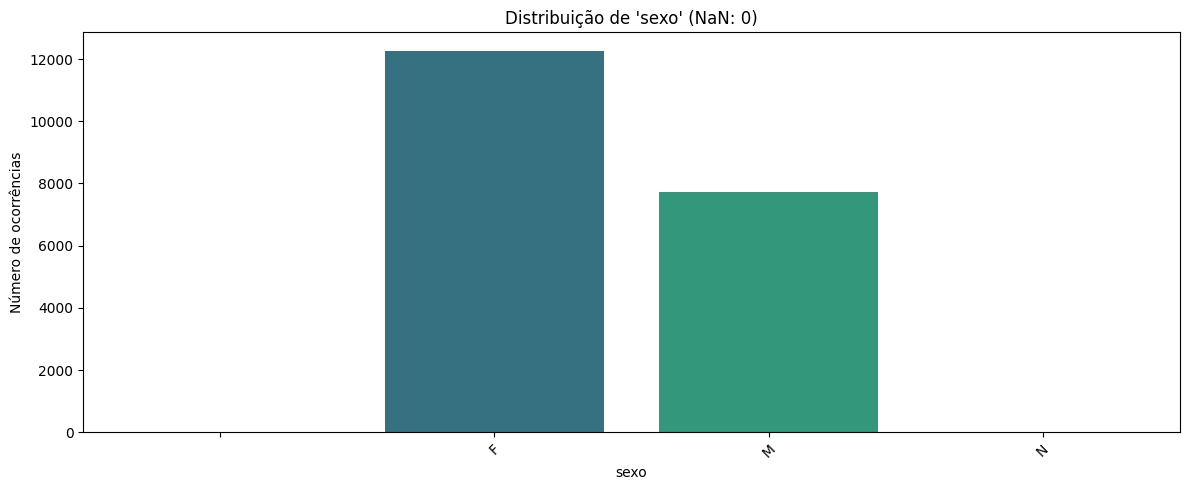


Distribuição de 'estado_civil' (valores ausentes: 0)


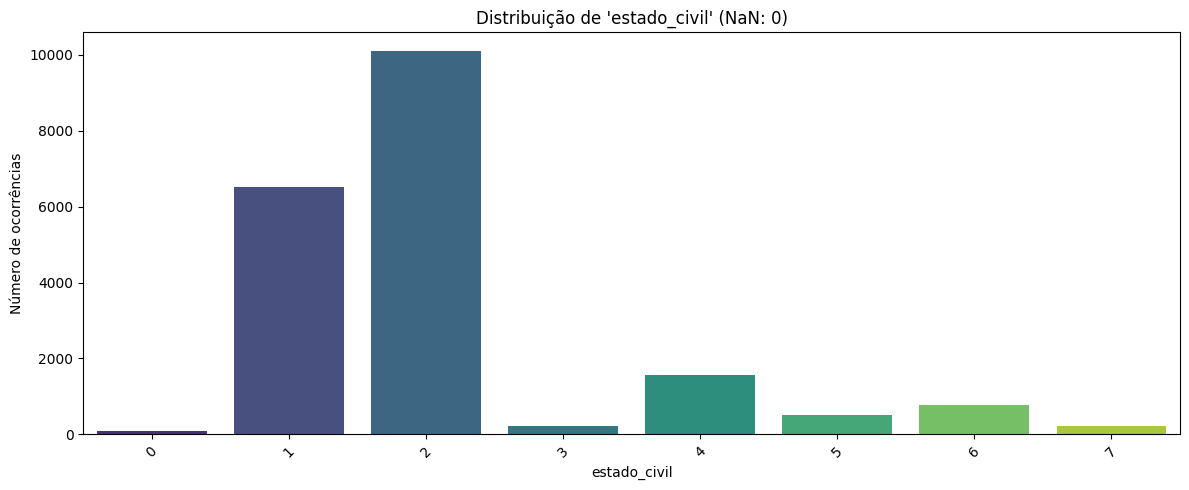


Distribuição de 'grau_instrucao' (valores ausentes: 0)


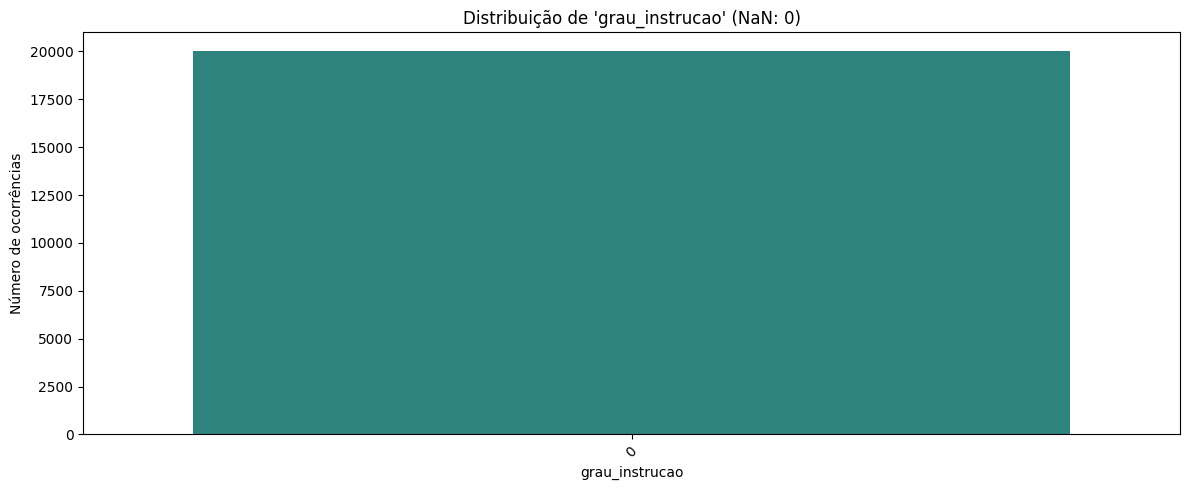


Distribuição de 'nacionalidade' (valores ausentes: 0)


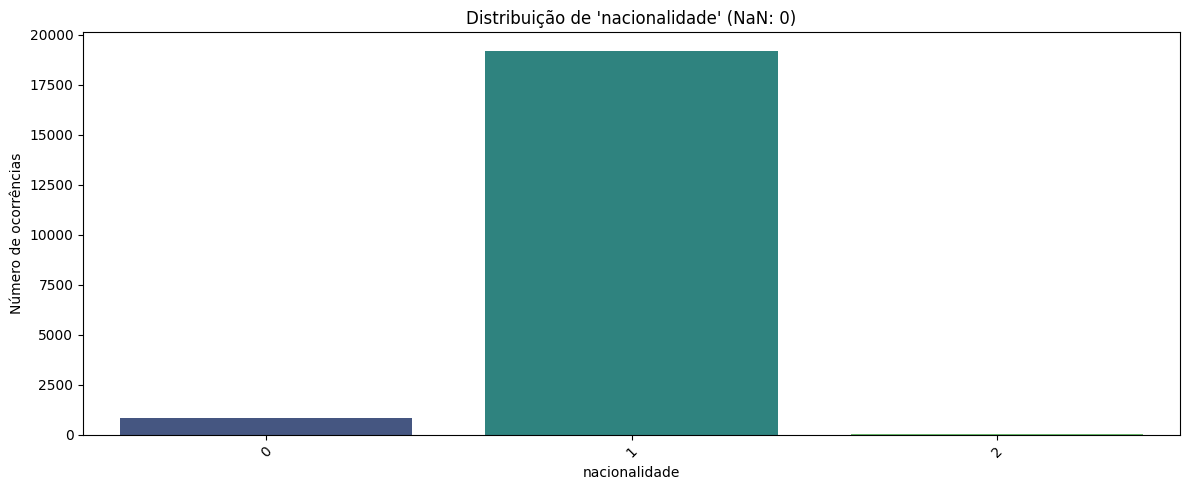


Distribuição de 'estado_onde_nasceu' (valores ausentes: 0)


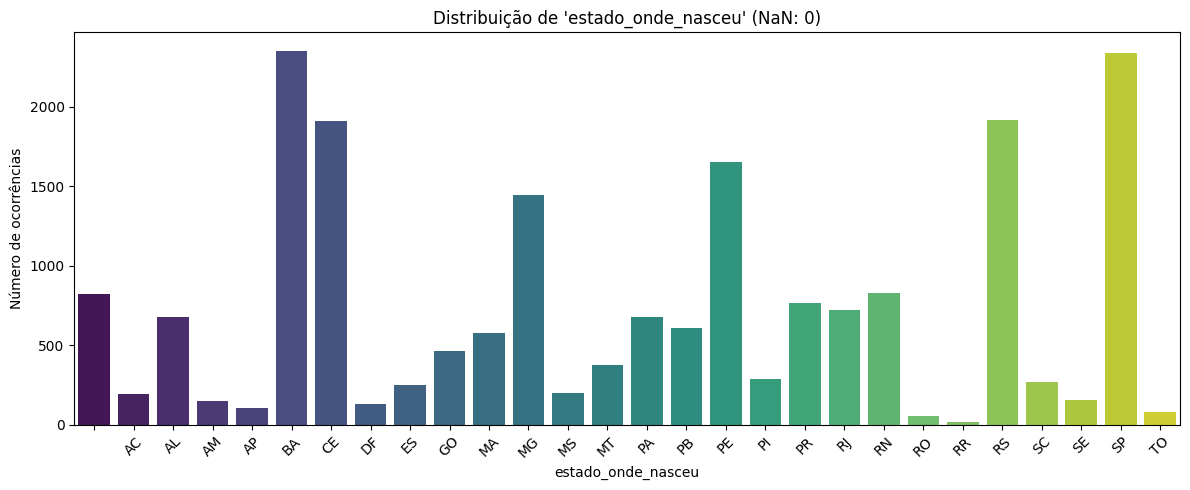


Distribuição de 'estado_onde_reside' (valores ausentes: 0)


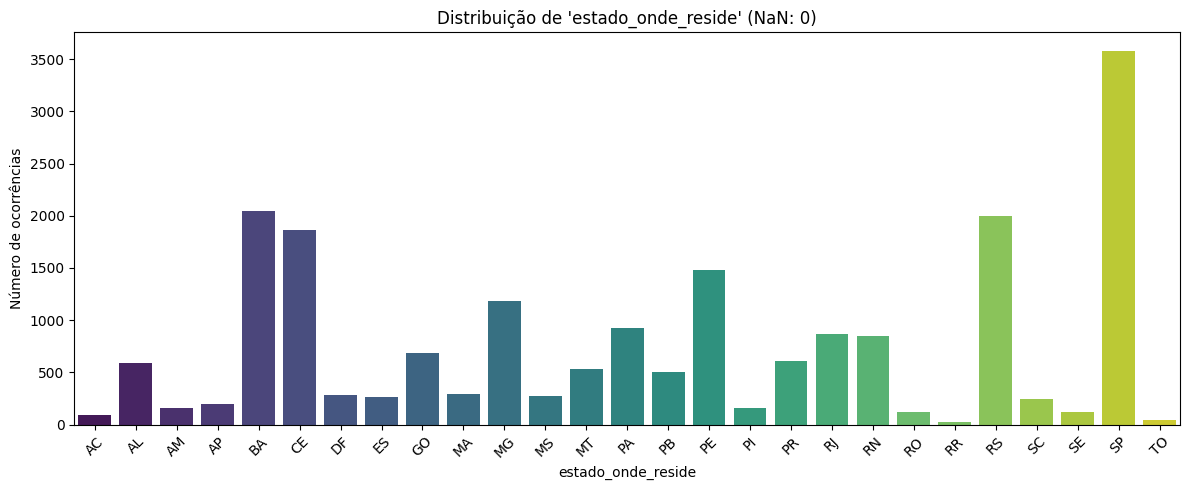


Distribuição de 'possui_telefone_residencial' (valores ausentes: 0)


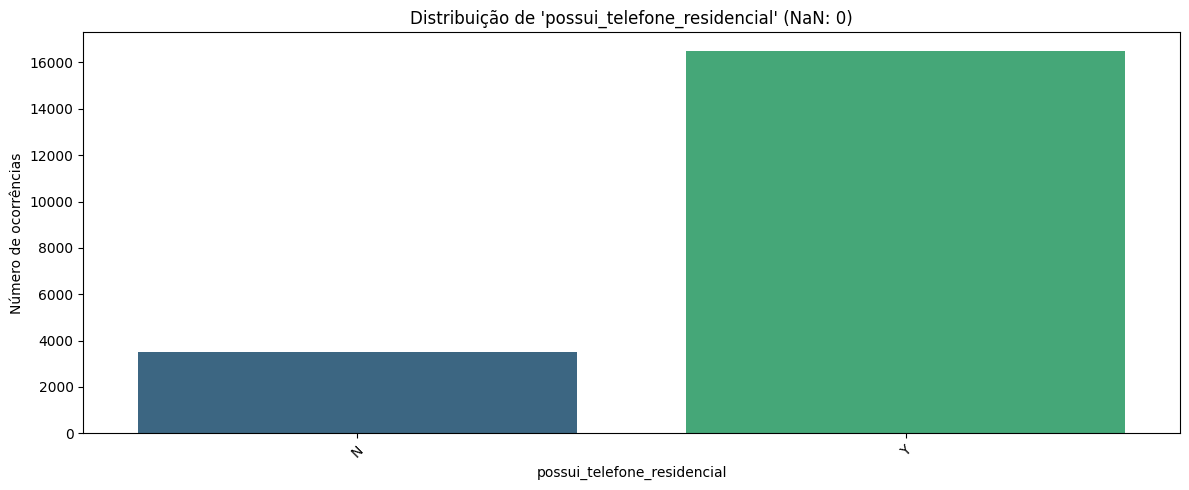


Distribuição de 'codigo_area_telefone_residencial' (valores ausentes: 0)


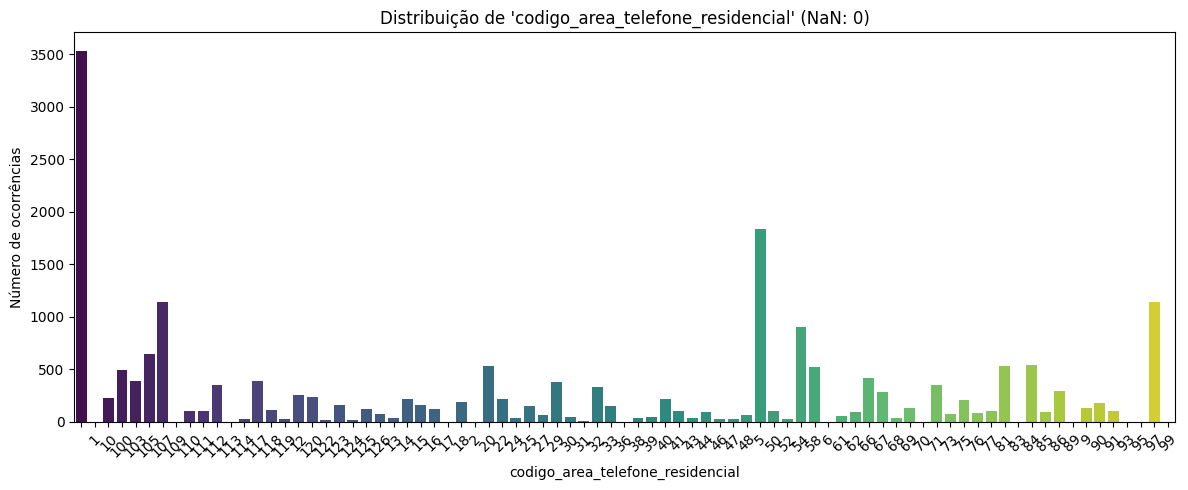


Distribuição de 'tipo_residencia' (valores ausentes: 536)


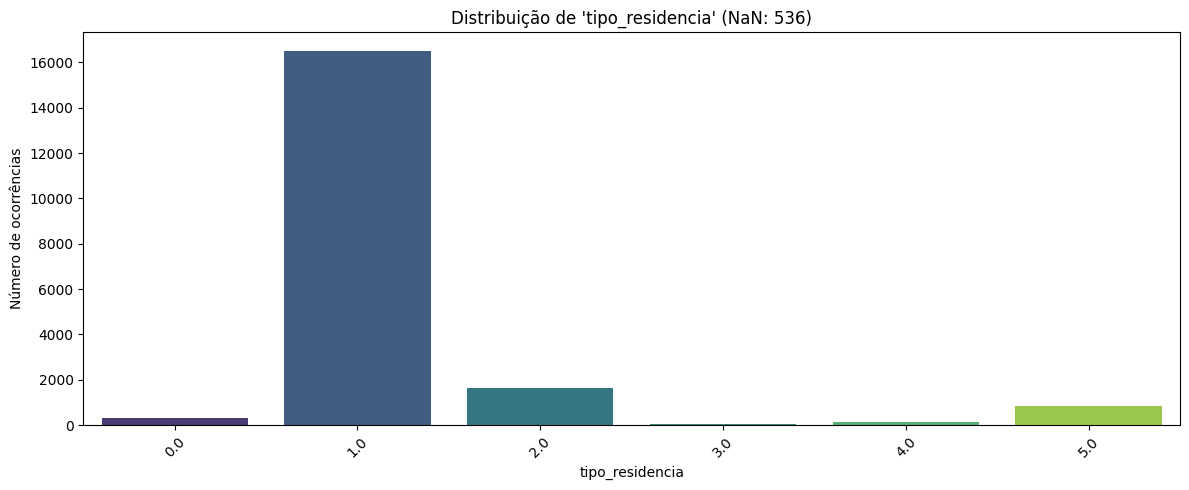


Distribuição de 'possui_telefone_celular' (valores ausentes: 0)


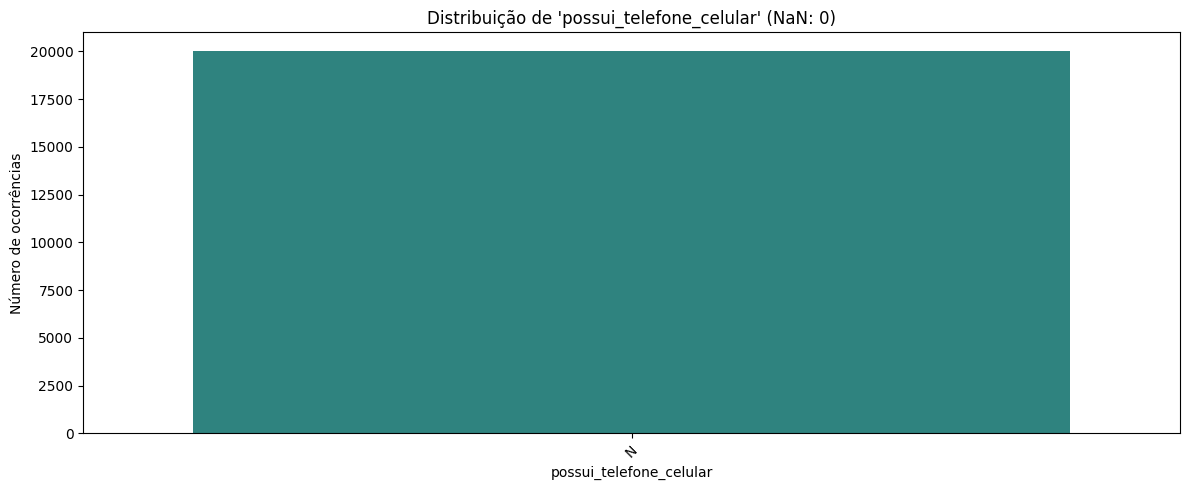


Distribuição de 'possui_email' (valores ausentes: 0)


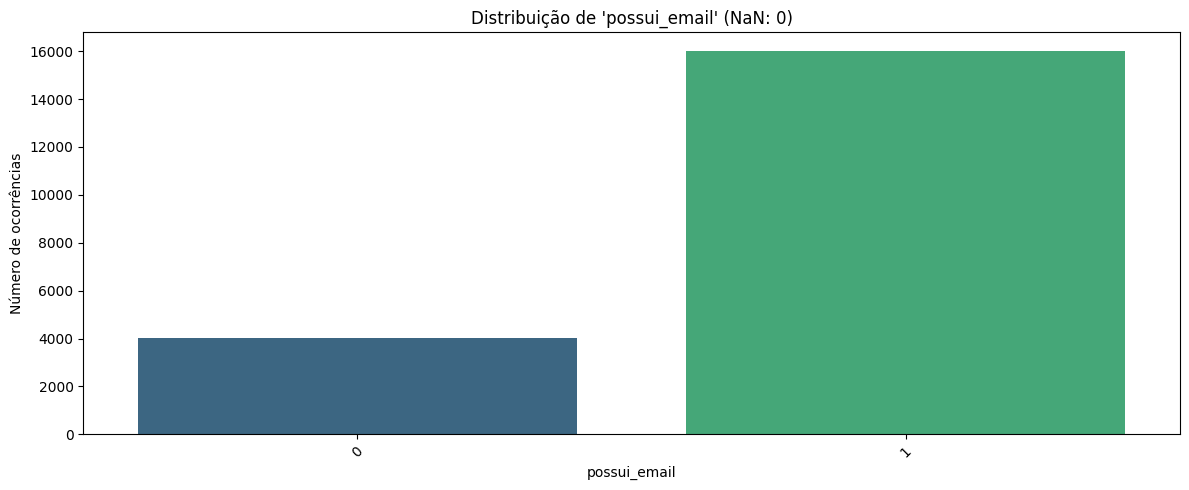


Distribuição de 'possui_cartao_visa' (valores ausentes: 0)


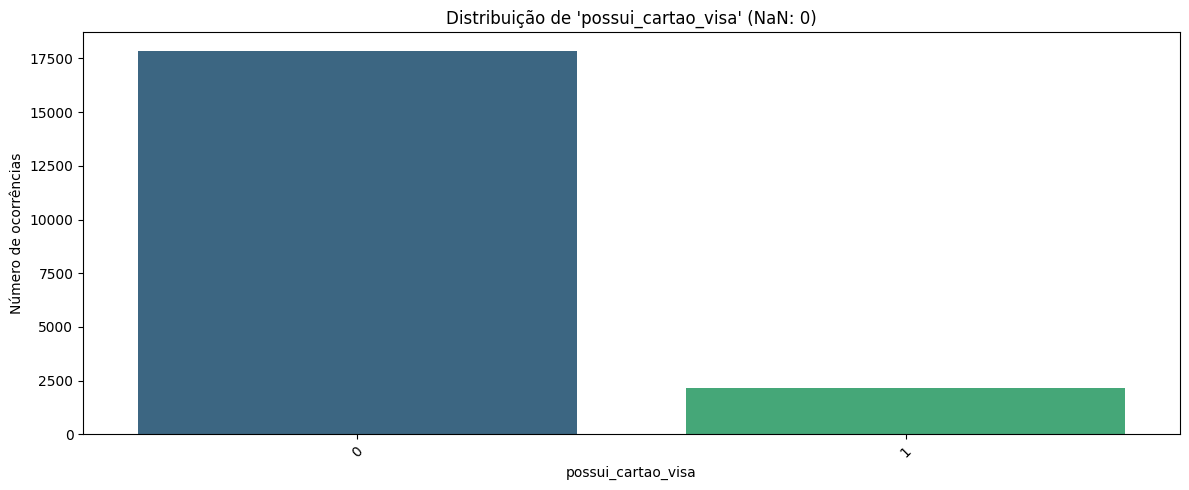


Distribuição de 'possui_cartao_mastercard' (valores ausentes: 0)


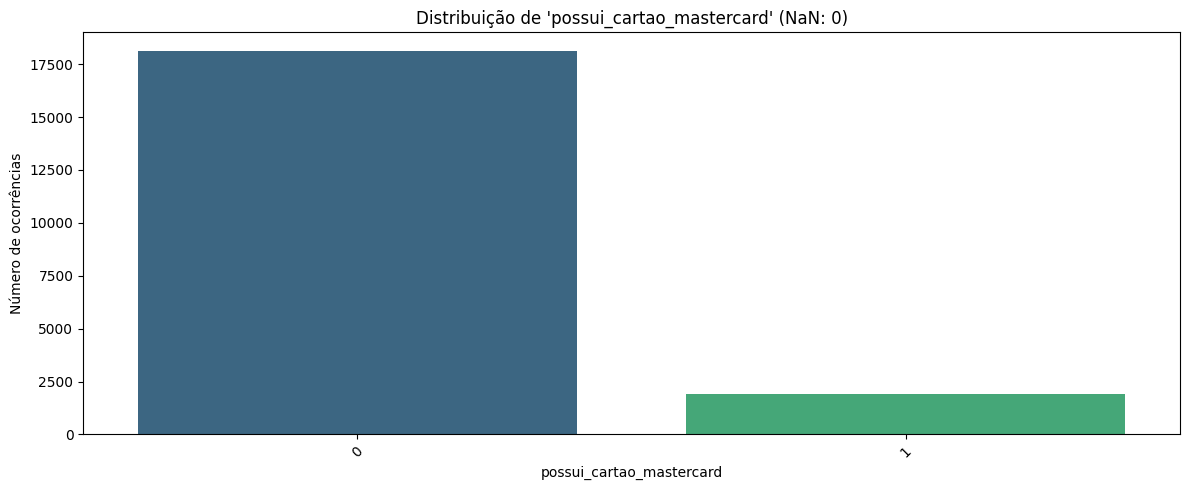


Distribuição de 'possui_cartao_diners' (valores ausentes: 0)


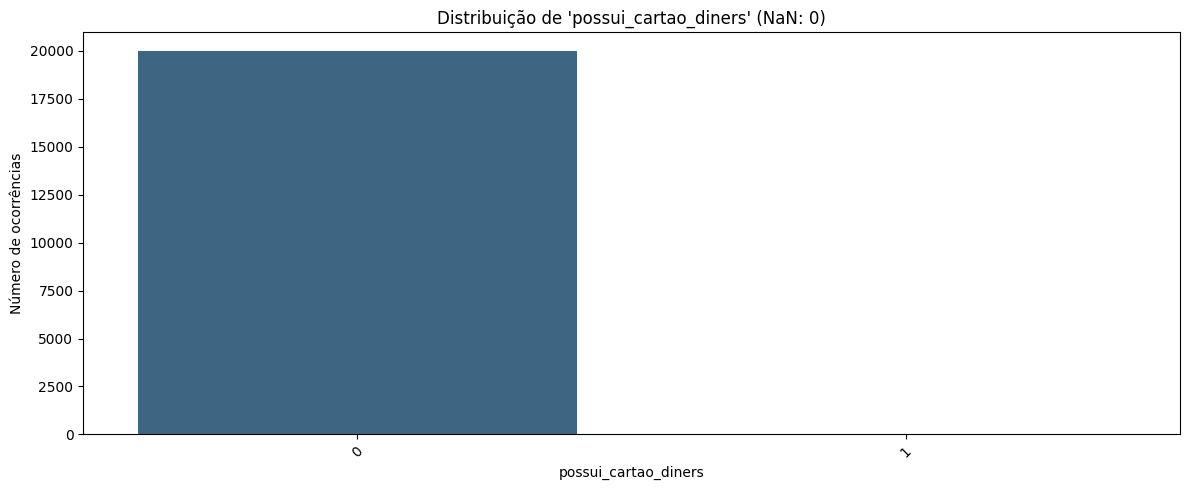


Distribuição de 'possui_cartao_amex' (valores ausentes: 0)


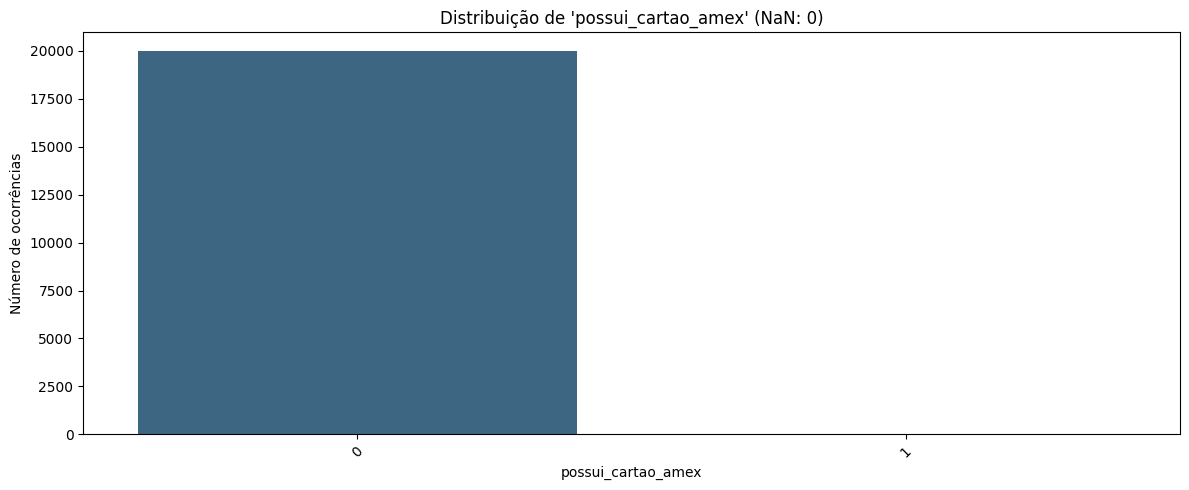


Distribuição de 'possui_outros_cartoes' (valores ausentes: 0)


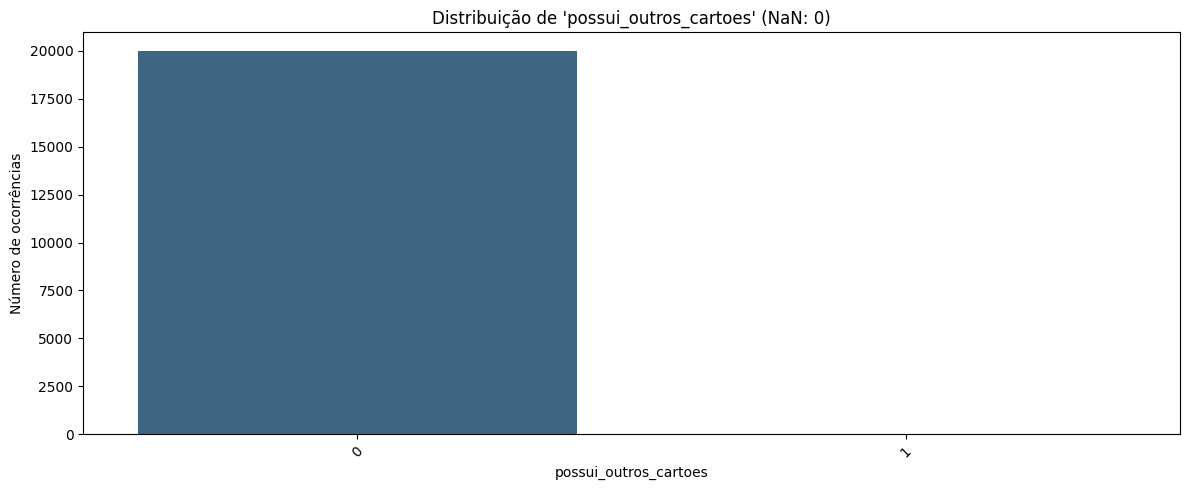


Distribuição de 'qtde_contas_bancarias' (valores ausentes: 0)


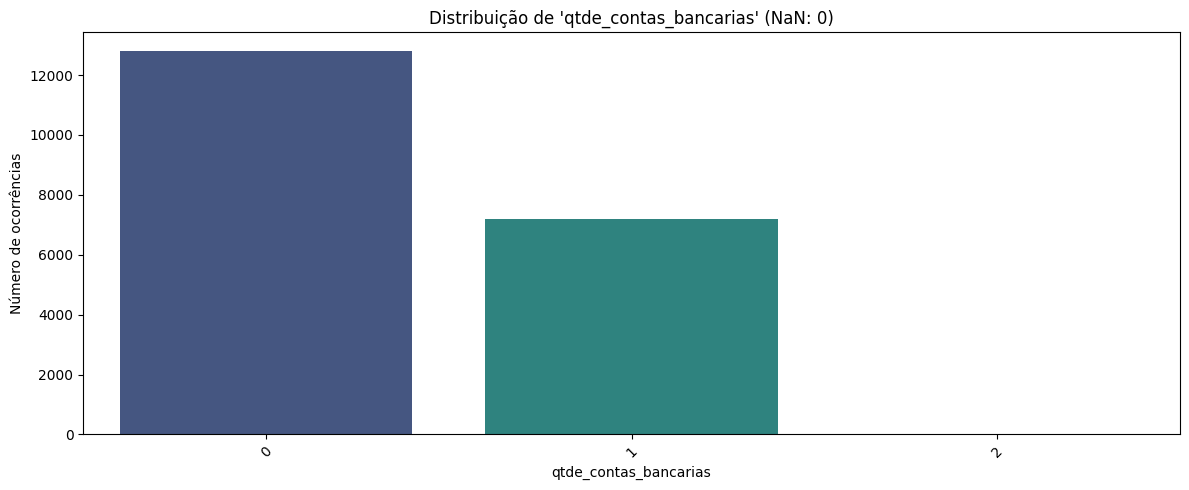


Distribuição de 'qtde_contas_bancarias_especiais' (valores ausentes: 0)


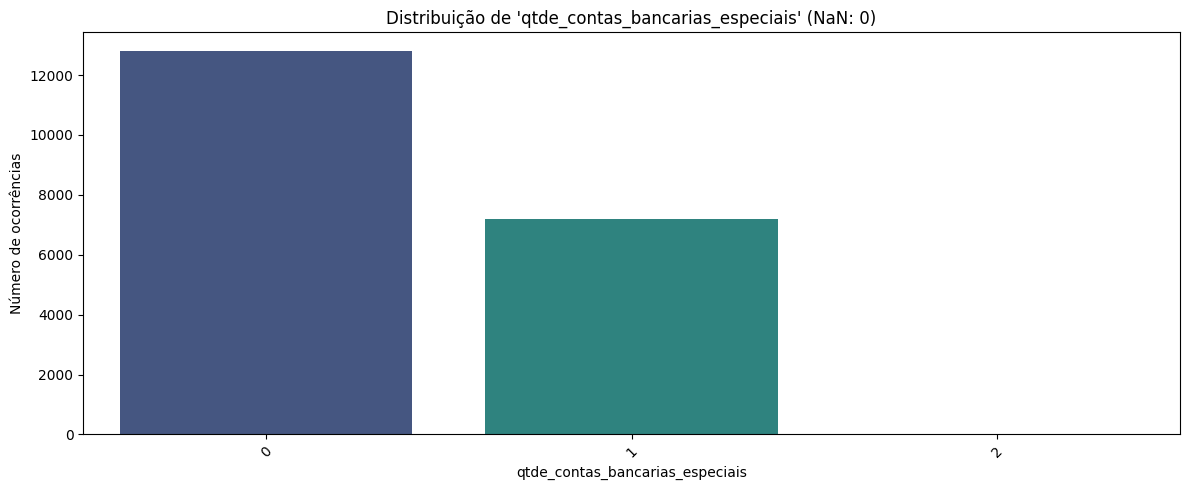


Distribuição de 'possui_carro' (valores ausentes: 0)


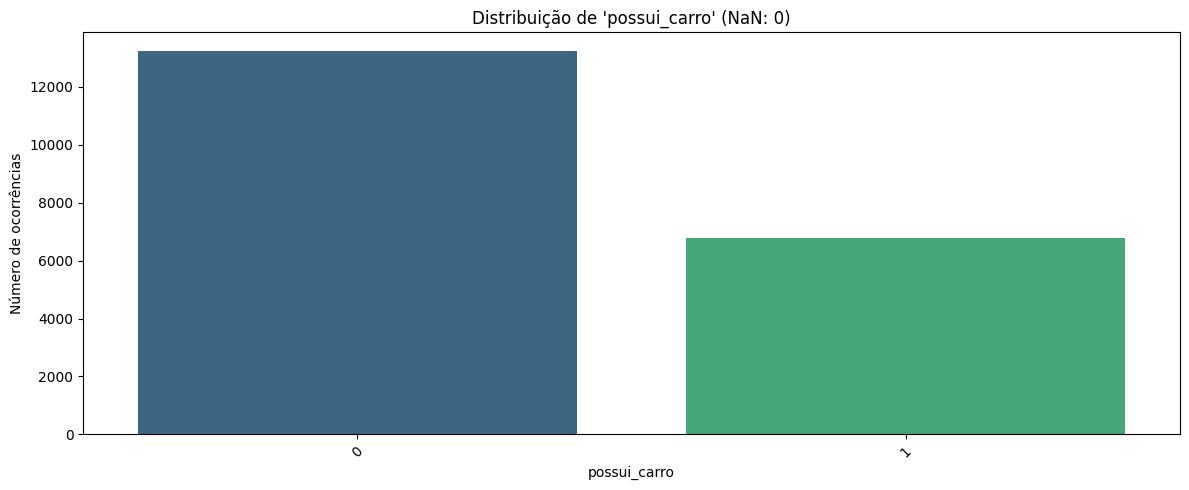


Distribuição de 'vinculo_formal_com_empresa' (valores ausentes: 0)


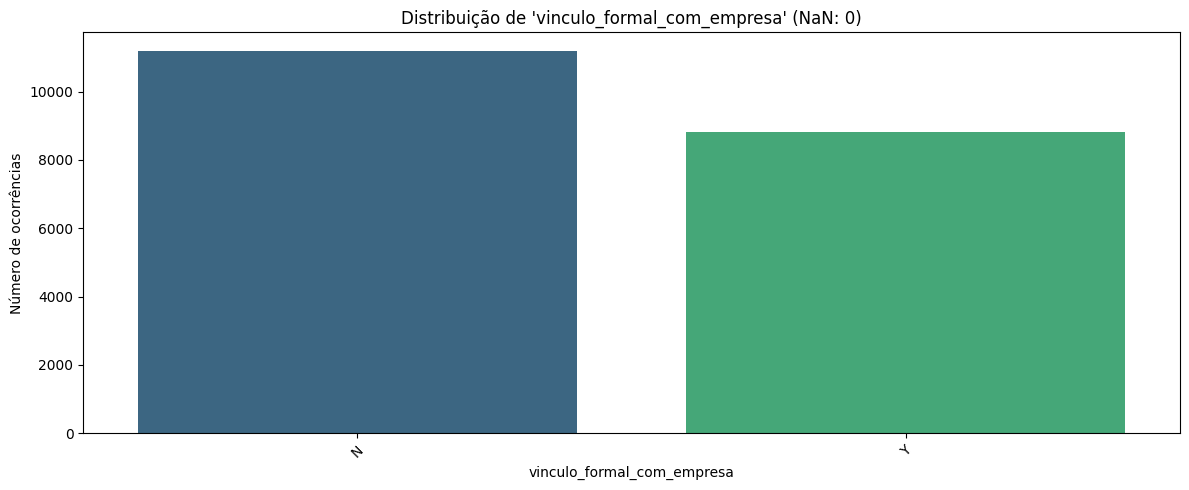


Distribuição de 'estado_onde_trabalha' (valores ausentes: 0)


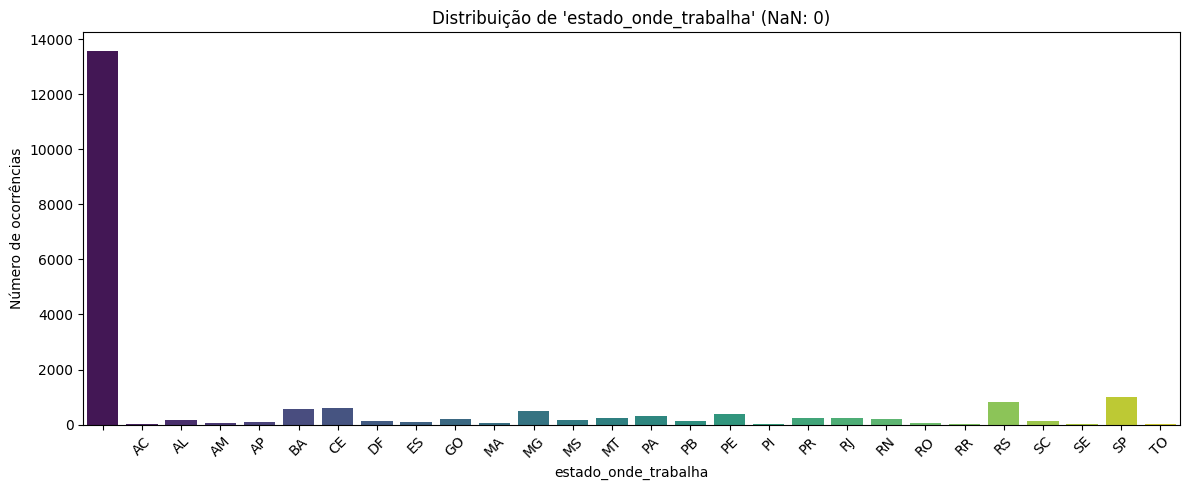


Distribuição de 'possui_telefone_trabalho' (valores ausentes: 0)


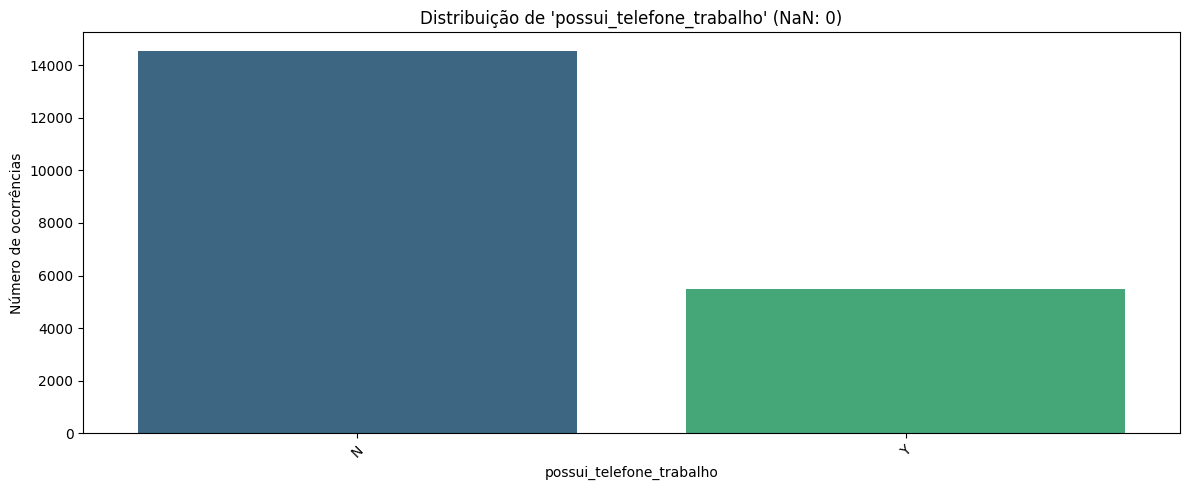


Distribuição de 'codigo_area_telefone_trabalho' (valores ausentes: 0)


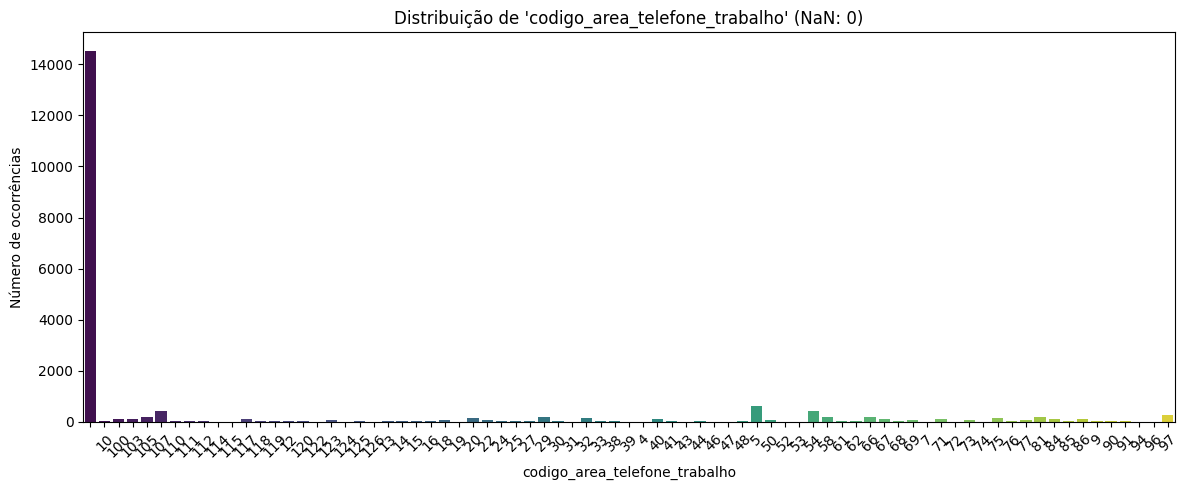


Distribuição de 'meses_no_trabalho' (valores ausentes: 0)


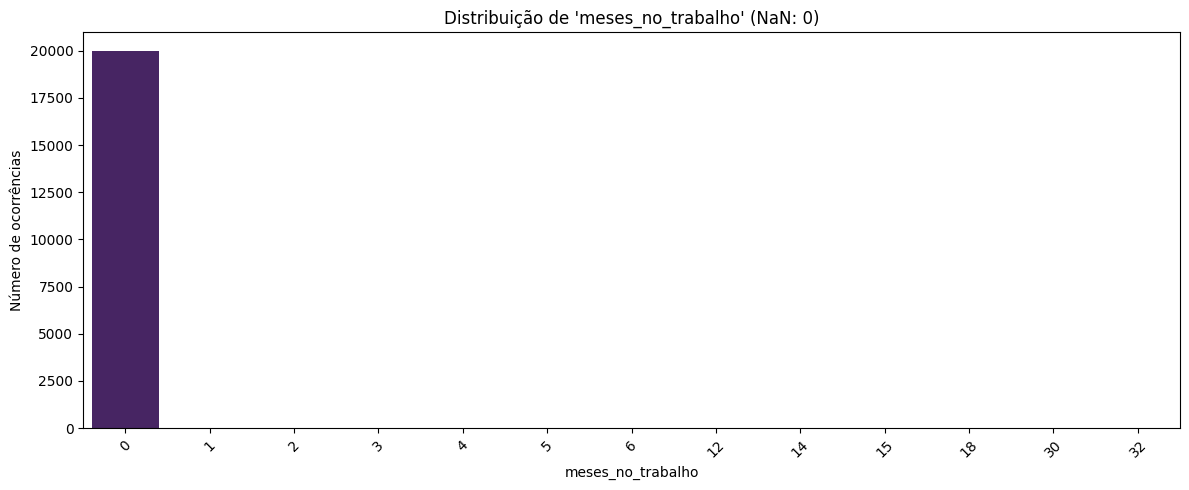


Distribuição de 'profissao' (valores ausentes: 3097)


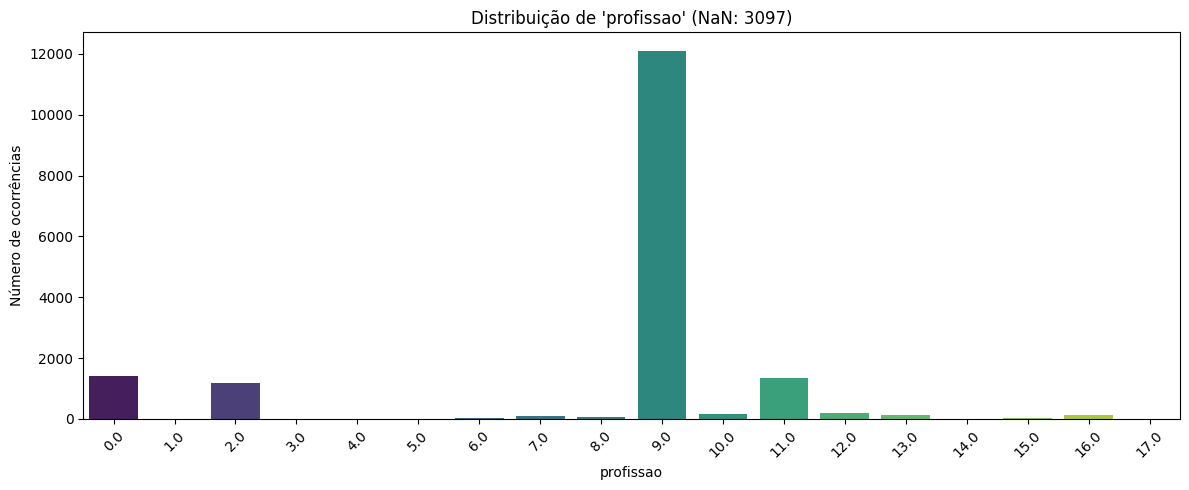


Distribuição de 'ocupacao' (valores ausentes: 2978)


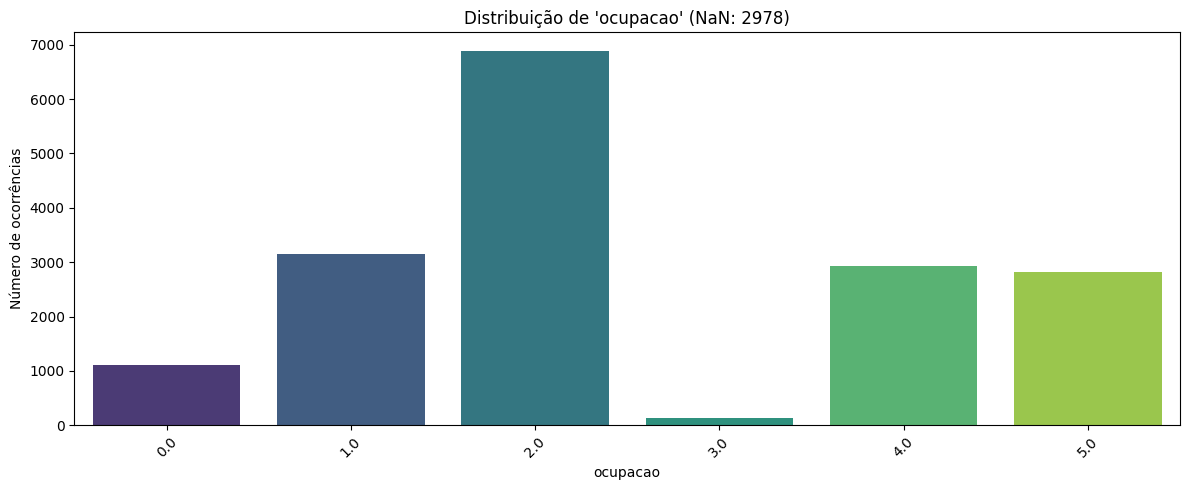


Distribuição de 'profissao_companheiro' (valores ausentes: 11514)


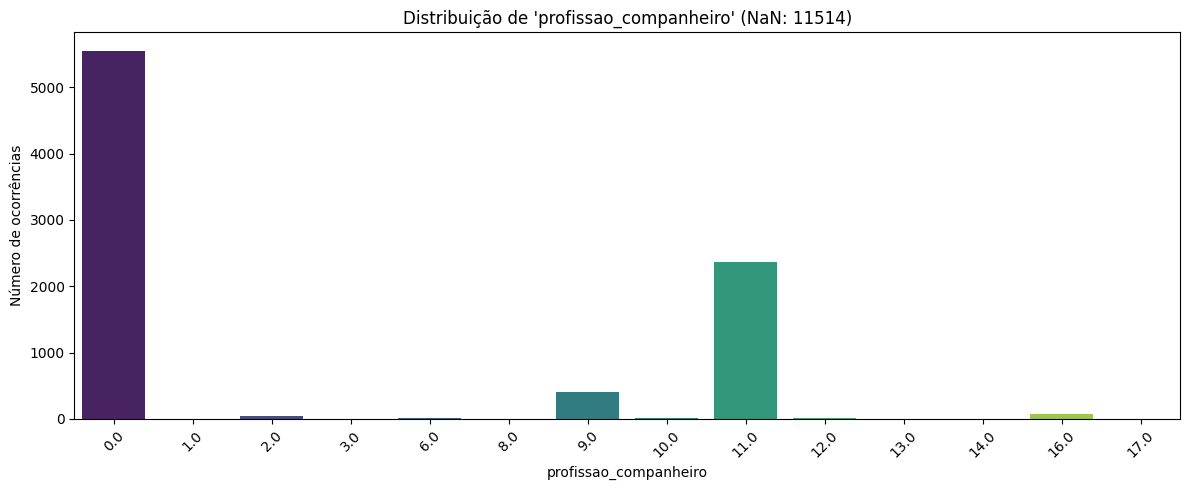


Distribuição de 'grau_instrucao_companheiro' (valores ausentes: 12860)


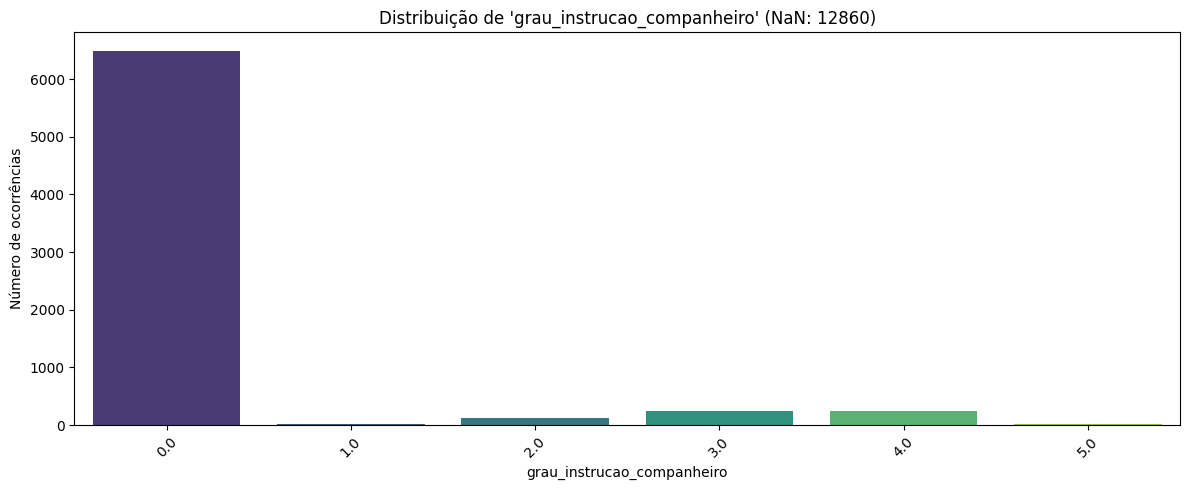


Distribuição de 'local_onde_reside' (valores ausentes: 0)


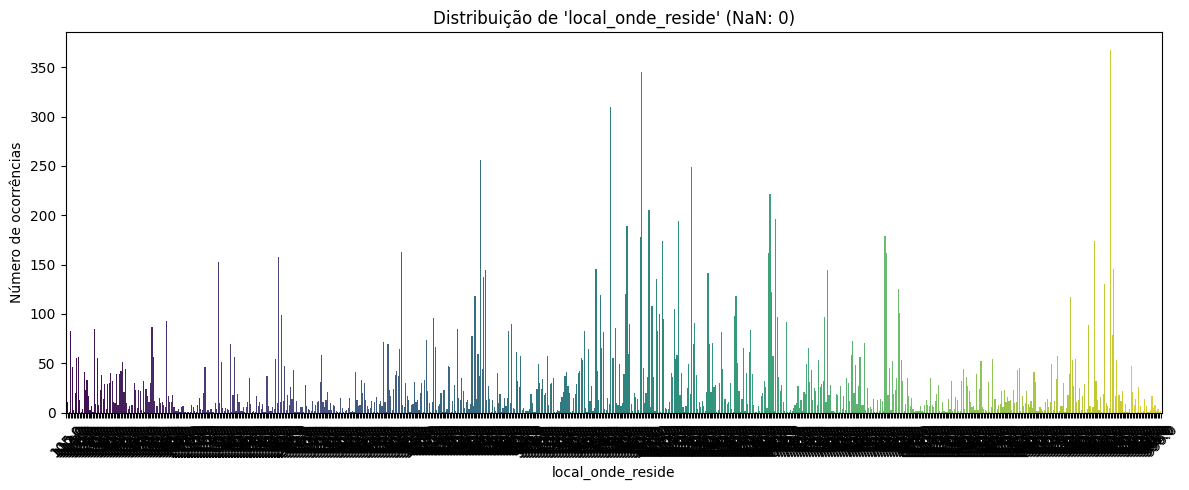


Distribuição de 'local_onde_trabalha' (valores ausentes: 0)


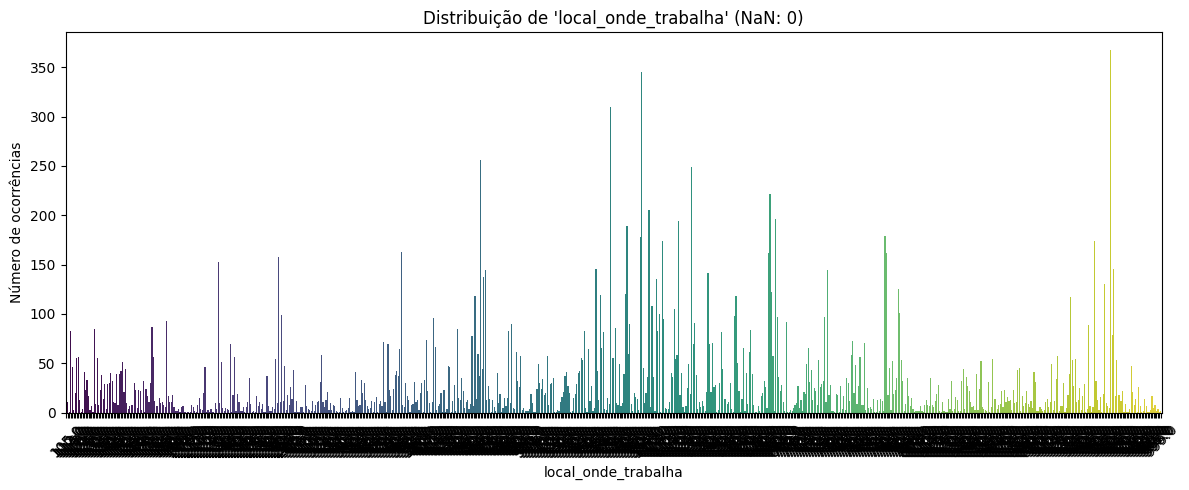


Distribuição de 'meses_na_residencia' (valores ausentes: 1450)


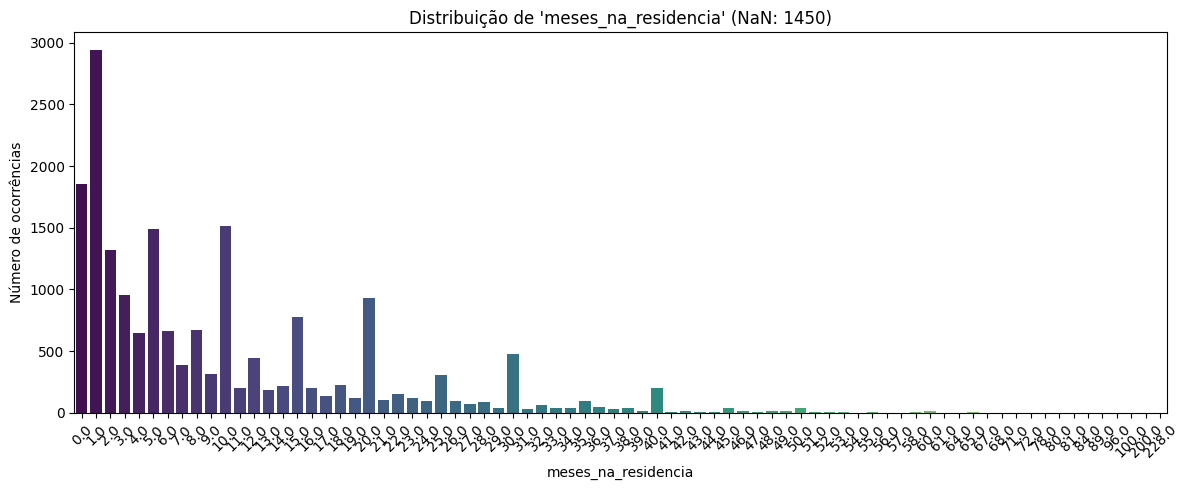


Distribuição de 'valor_patrimonio_pessoal' (valores ausentes: 0)


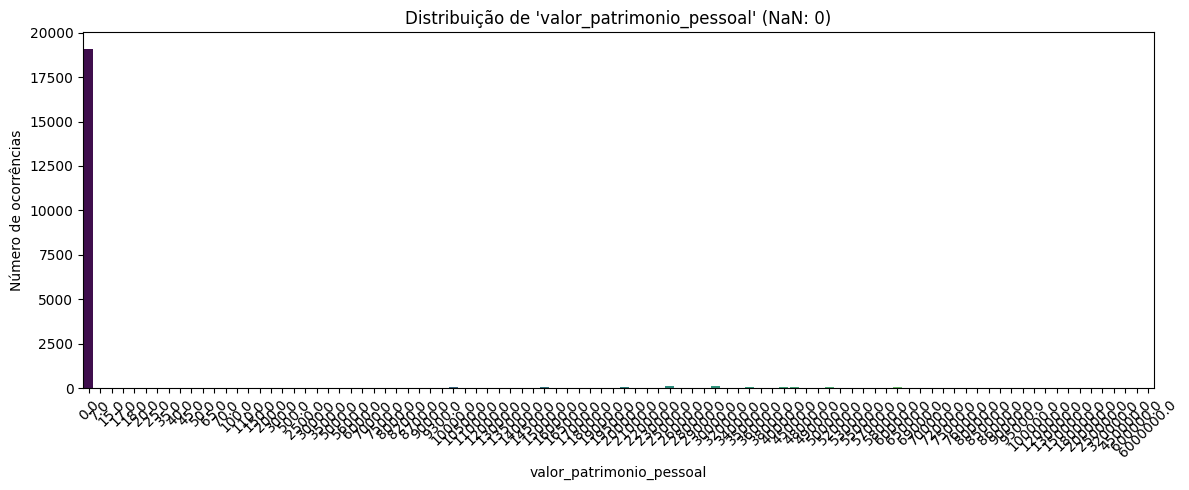

In [25]:
# Lista de features não contínuas para exibição em barplot
features_nao_contínuas = [
    'produto_solicitado', 
    'dia_vencimento', 
    'forma_envio_solicitacao',
    'tipo_endereco', 
    'sexo', 
    'estado_civil', 
    'grau_instrucao', 
    'nacionalidade',
    'estado_onde_nasceu', 
    'estado_onde_reside', 
    'possui_telefone_residencial',
    'codigo_area_telefone_residencial', 
    'tipo_residencia', 
    'possui_telefone_celular',
    'possui_email', 
    'possui_cartao_visa', 
    'possui_cartao_mastercard',
    'possui_cartao_diners', 
    'possui_cartao_amex', 
    'possui_outros_cartoes',
    'qtde_contas_bancarias', 
    'qtde_contas_bancarias_especiais', 
    'possui_carro',
    'vinculo_formal_com_empresa', 
    'estado_onde_trabalha', 
    'possui_telefone_trabalho',
    'codigo_area_telefone_trabalho', 
    'meses_no_trabalho', 'profissao',
    'ocupacao', 
    'profissao_companheiro', 
    'grau_instrucao_companheiro',
    'local_onde_reside', 
    'local_onde_trabalha',
]

# Loop por cada coluna da lista
for col in features_nao_contínuas:
    missing = df[col].isna().sum()
    print(f"\nDistribuição de '{col}' (valores ausentes: {missing})")

    # Contagem das ocorrências (ignorando os NaN)
    counts = df[col].value_counts(dropna=True).sort_index()

    # Criação de um DataFrame para exibição
    data = pd.DataFrame({
        'value': counts.index.astype(str),
        'occurrences': counts.values
    })

    # Exibição do gráfico
    plt.figure(figsize=(12, 5))
    sns.barplot(data=data, x='value', y='occurrences', hue='value', palette='viridis', legend=False)
    plt.title(f"Distribuição de '{col}' (NaN: {missing})")
    plt.xlabel(col)
    plt.ylabel("Número de ocorrências")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


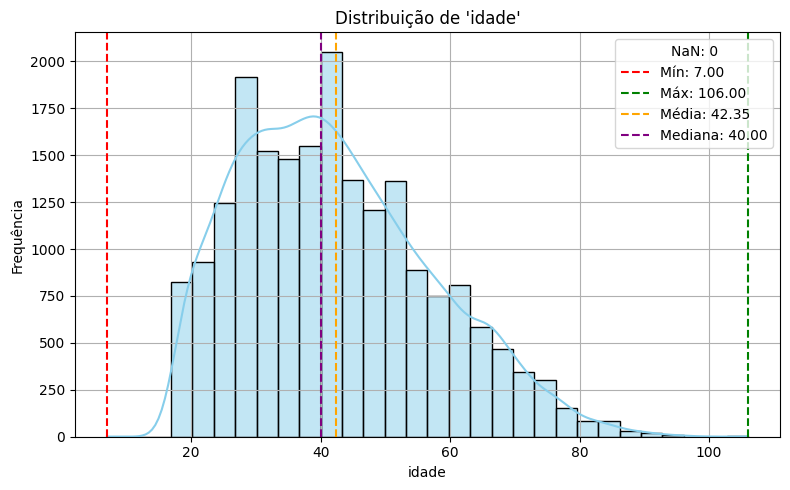

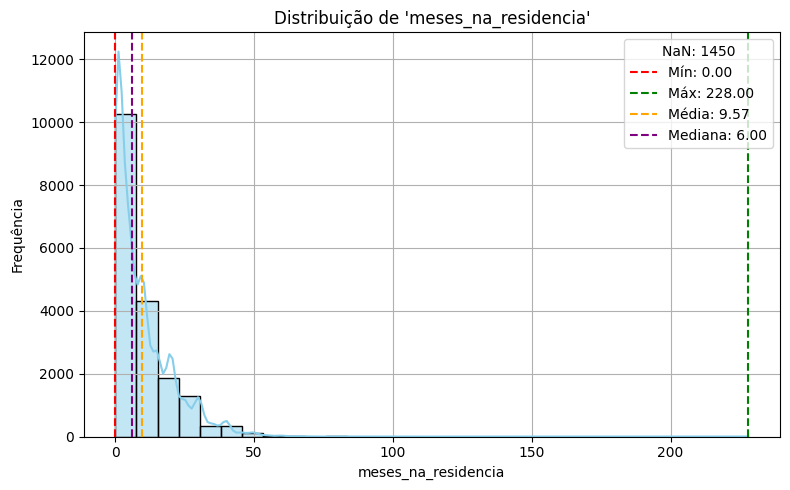

In [27]:
# variáveis contínuas a analisar
variaveis = ['idade', 'meses_na_residencia']

for var in variaveis:
    # Estatísticas básicas
    data = df[var]
    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    median_val = data.median()
    nan_count = data.isna().sum()

    # Exibição do gráfico
    plt.figure(figsize=(8, 5))
    sns.histplot(data=data, kde=True, bins=30, color='skyblue')
    plt.title(f"Distribuição de '{var}'")
    plt.xlabel(var)
    plt.ylabel("Frequência")

    # Exibição das linhas de estatísticas
    plt.axvline(min_val, color='red', linestyle='--', label=f'Mín: {min_val:.2f}')
    plt.axvline(max_val, color='green', linestyle='--', label=f'Máx: {max_val:.2f}')
    plt.axvline(mean_val, color='orange', linestyle='--', label=f'Média: {mean_val:.2f}')
    plt.axvline(median_val, color='purple', linestyle='--', label=f'Mediana: {median_val:.2f}')
    
    # Exibição do número de NaN
    plt.legend(title=f"NaN: {nan_count}", loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Observando essas distribuições, podemos elaborar esta lista de features para as quais os dados parecem muito desequilibrados ou incorretos. Por exemplo, qtde_contas_bancarias e qtde_contas_bancarias_especiais têm a mesma distribuição, então será necessário remover uma delas:

- tipo_endereco # Esta coluna veio totalmente preenchida com "1"

- grau_instrucao # Esta coluna veio totalmente preenchida com zeros

- nacionalidade # Esta coluna veio totalmente preenchida com "1"

- tipo_residencia # Esta coluna veio totalmente preenchida com "1"

- possui_telefone_celular # Esta coluna veio totalmente preenchida com "N"

- possui_cartao_diners # Esta coluna veio totalmente preenchida com zeros

- possui_cartao_amex # Esta coluna veio totalmente preenchida com zeros

- possui_outros_cartoes # Esta coluna veio totalmente preenchida com zeros

- qtde_contas_bancarias

- qtde_contas_bancarias_especiais # Conteúdo idêntico ao campo 'qtde_contas_bancarias'

- estado_onde_trabalha

- codigo_area_telefone_trabalho

- meses_no_trabalho # Esta coluna veio totalmente preenchida com zeros

- profissao # Esta coluna veio totalmente preenchida com '9'

- profissao_companheiro # Esta coluna veio totalmente preenchida com zeros

- grau_instrucao_companheiro # Esta coluna veio totalmente preenchida com zeros

Vamos criar a lista de features úteis para o treinamento com LightGBM e comparar com a lista que acabamos de elaborar para determinar quais features são realmente inúteis e podem ser removidas.

## Cálculo da importância das variáveis com LGBMClassifier

Este código prepara os dados para o treinamento de um modelo LightGBM. Ele codifica as colunas categóricas com LabelEncoder para converter as categorias em números. Em seguida, separa os dados em variáveis explicativas (X) e variável alvo (y).  
  
O modelo LGBMClassifier é então treinado com esses dados. Após o treinamento, a importância de cada variável é extraída via feature_importances_. Assim, conhecemos as features mais importantes para o treinamento do modelo, bem como aquelas que podem ser removidas.

[LightGBM] [Info] Number of positive: 10000, number of negative: 10000
[LightGBM] [Info] Total Bins 1544
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


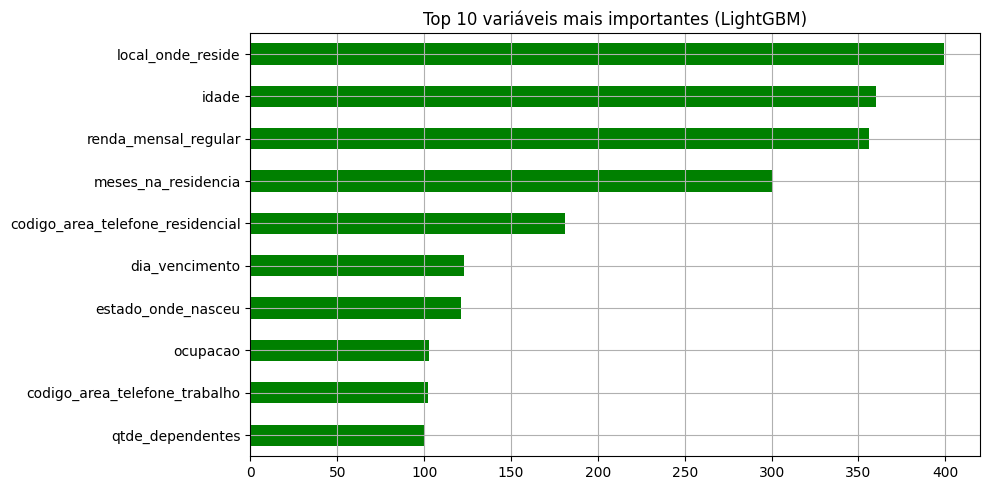

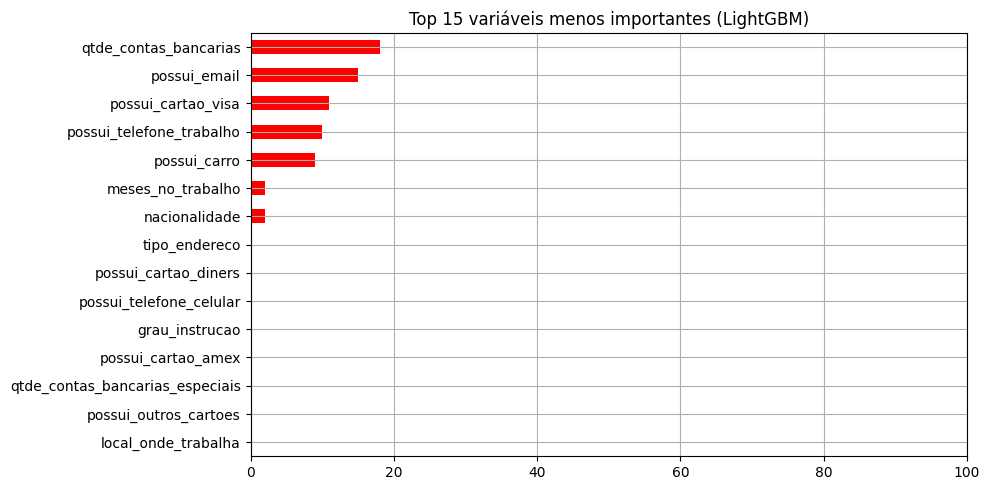

In [7]:
# Preparação
df_model = train_df.copy()

# Codificação simples das colunas categóricas
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Separação X / y
X = df_model.drop(columns=['id_solicitante', 'inadimplente'])
y = df_model['inadimplente']

# Modelo inicial
model = LGBMClassifier(
    force_row_wise=True,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)
model.fit(X, y)

# Importância
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

# Seleção das 10 variáveis mais importantes e 10 menos importantes
top_10 = importances_sorted.head(10)
bottom_15 = importances_sorted.tail(15)

# Exibição das 10 variáveis mais importantes
plt.figure(figsize=(10, 5))
top_10.plot(kind='barh', color='green')
plt.title("Top 10 variáveis mais importantes (LightGBM)")
plt.gca().invert_yaxis()
plt.xlim(0, 420)
plt.grid(True)
plt.tight_layout()
plt.show()

# Exibição das 15 variáveis menos importantes
plt.figure(figsize=(10, 5))
bottom_15.plot(kind='barh', color='red')
plt.title("Top 15 variáveis menos importantes (LightGBM)")
plt.gca().invert_yaxis()
plt.xlim(0,100)
plt.grid(True)
plt.tight_layout()
plt.show()


O resultado do cálculo das features menos importantes confirma nossa análise exploratória das distribuições. A próxima etapa, portanto, é encontrar um equilíbrio para remover as features menos úteis sem eliminar muitas.

In [8]:
# Seleção segundo um limite
limite_importancia = 5
features_a_manter = importances_sorted[importances_sorted >= limite_importancia].index.tolist()

# Colunas a manter + o alvo + eventualmente id_solicitante
colunas_a_manter_treino = features_a_manter + ['inadimplente', 'id_solicitante']
colunas_a_manter_teste = features_a_manter + ['id_solicitante']

# Remover as colunas não desejadas
train_df_reduzido = train_df[colunas_a_manter_treino].copy()
test_df_reduzido = test_df[colunas_a_manter_teste].copy()

num_variaveis_removidas = len(importances_sorted) - len(features_a_manter)
print(f"Número de variáveis mantidas: {len(features_a_manter)}")
print(f"Número de variáveis removidas: {num_variaveis_removidas}")

Número de variáveis mantidas: 30
Número de variáveis removidas: 10


Após várias tentativas, variando o número de features removidas, o equilíbrio que proporciona o melhor resultado é eliminar as 10 features menos úteis (que também são aquelas com erros de extração). São elas:  
- 'meses_no_trabalho'  
- 'nacionalidade'  
- 'tipo_endereco'  
- 'possui_cartao_diners'
- 'possui_telefone_celular'
- 'grau_instrucao'
- 'possui_cartao_amex'
- 'qtde_contas_bancarias_especiais'
- 'possui_outros_cartoes'
- 'local_onde_trabalha'

## Pré-processamento dos dados, tratamento de valores ausentes (imputers) e escalonamento

A função preprocess prepara os DataFrames para treinamento e predição :

- Ela separa as colunas em categóricas e numéricas para aplicar imputações adequadas.

- Na primeira chamada (fit_imputers=True), ela cria e treina os imputers, substituindo os valores ausentes.

- Depois, ela codifica as colunas categóricas com OneHot, transformando cada categoria em uma coluna binária.

- Ela retorna o DataFrame transformado, assim como os imputers, para reutilização no DataFrame de teste e para garantir que as mesmas transformações aplicadas no conjunto de treinamento sejam aplicadas exatamente no conjunto de teste.

In [9]:
# --- Pré-processamento ---
def preprocess(df, imputers=None, fit_imputers=False):
    df = df.copy()

    # Identificar as colunas categóricas e numéricas
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Imputação dos valores faltantes
    if fit_imputers:
        # Criar os imputers para o fit
        cat_imputer = SimpleImputer(strategy='most_frequent')  # Substitui valores faltantes categóricos pelo mais frequente
        num_imputer = SimpleImputer(strategy='median')         # Substitui valores faltantes numéricos pela mediana

        # Aplicar os imputers e guardar para reutilização futura
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
        df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

        imputers = {'cat_imputer': cat_imputer, 'num_imputer': num_imputer}
    else:
        # Reutilizar os imputers já treinados passados como parâmetro
        df[categorical_cols] = imputers['cat_imputer'].transform(df[categorical_cols])
        df[numeric_cols] = imputers['num_imputer'].transform(df[numeric_cols])

    # Codificação OneHot das colunas categóricas (removendo a primeira categoria para evitar multicolinearidade)
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    return df, imputers


- Começamos separando as variáveis explicativas X e o alvo y.

- O pré-processamento é aplicado ao conjunto de treino com a criação dos imputers (imputação dos valores faltantes + codificação).

- Para o conjunto de teste, aplicamos os mesmos imputers para manter a consistência das transformações.

- Em seguida, harmonizamos as colunas entre treino e teste: adicionamos as colunas que faltam no teste preenchendo com zeros e removemos as colunas extras.

- Depois, garantimos que a ordem das colunas seja idêntica nos dois DataFrames.

In [10]:
# Separar features e alvo
X = train_df_reduzido.drop(columns=['id_solicitante', 'inadimplente'])
y = train_df_reduzido['inadimplente']

# Pré-processamento treino (imputação + codificação)
X_processado, imputers = preprocess(X, fit_imputers=True)

# Pré-processamento teste (com mesmos imputers)
test_processado, _ = preprocess(test_df_reduzido.drop(columns=['id_solicitante']), imputers=imputers, fit_imputers=False)

# --- Harmonização treino/teste ---
# Adicionar colunas que faltam no test_processado com zeros
colunas_faltando = set(X_processado.columns) - set(test_processado.columns)
for col in colunas_faltando:
    test_processado[col] = 0

# Remover colunas extras que existem no test_processado mas não no X_processado
colunas_extras = set(test_processado.columns) - set(X_processado.columns)
test_processado.drop(columns=colunas_extras, inplace=True)

# Reordenar as colunas do test_processado para corresponder à ordem de X_processado
test_processado = test_processado[X_processado.columns]

Por fim, aplicamos uma normalização padrão (média 0, desvio padrão 1) nos dados de treino e transformamos os dados de teste com o mesmo scaler para garantir uma escala consistente.  
  
Não é necessário aplicar um scaler para os modelos que vou usar (Random Forest, XGBoost e LightGBM), mas depois de testar com e sem scaler, os resultados são melhores com o scaler.

In [11]:
# --- Escalonamento ---
scaler = StandardScaler()
# Ajustar o scaler nos dados de treino e transformar
X_proc = pd.DataFrame(scaler.fit_transform(X_processado), columns=X_processado.columns)
# Transformar os dados de teste com o mesmo scaler
test_proc = pd.DataFrame(scaler.transform(test_processado), columns=test_processado.columns)

Esta linha divide os dados pré-processados (X_processed e y) em dois conjuntos:

- um conjunto de treinamento (X_train, y_train) que conterá 80% dos dados,

- um conjunto de validação (X_val, y_val) com os 20% restantes.

A validação serve para avaliar o desempenho do modelo em dados não vistos durante o treinamento.

O parâmetro random_state=42 fixa a semente aleatória para que a divisão seja reprodutível.

In [12]:
# --- Separação treino / validação ---
X_train, X_val, y_train, y_val = train_test_split(X_proc, y, test_size=0.2, random_state=42)

## Treinamento dos modelos e cálculo da acurácia e validação cruzada

Este bloco treina três modelos diferentes:

Random Forest,  
XGBoost,  
LightGBM  

Cada modelo é treinado com os dados de treinamento e depois testado no conjunto de validação.

A precisão (accuracy_score) é calculada para comparar o desempenho deles nessa validação.

In [13]:
# --- Modelagem (Random Forest + XGBoost) ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
print("Acurácia Random Forest:", accuracy_score(y_val, y_pred_rf))

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)
print("Acurácia XGBoost:", accuracy_score(y_val, y_pred_xgb))

# LightGBM
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_val)
print("Acurácia LightGBM:", accuracy_score(y_val, y_pred_lgbm))

Acurácia Random Forest: 0.578
Acurácia XGBoost: 0.58025
Acurácia LightGBM: 0.58625


In [14]:
# --- Validação cruzada ---
# Random Forest
scores_rf = cross_val_score(rf, X_proc, y, cv=5, scoring='accuracy')
print("Acurácia da validação cruzada (Random Forest):", scores_rf.mean())

# XGBoost
scores_xgb = cross_val_score(xgb, X_proc, y, cv=5, scoring='accuracy')
print("Acurácia da validação cruzada (XGBoost):", scores_xgb.mean())

# LightGBM
scores_lgbm = cross_val_score(lgbm, X_proc, y, cv=5, scoring='accuracy')
print("Acurácia da validação cruzada (LightGBM):", scores_lgbm.mean())


Acurácia da validação cruzada (Random Forest): 0.5782
Acurácia da validação cruzada (XGBoost): 0.58965
Acurácia da validação cruzada (LightGBM): 0.5964500000000001


C:\Users\romai\AppData\Local\Temp\ipykernel_13568\3492903753.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs.boxplot(accuracies, notch=True, labels=classif_models, patch_artist=True)


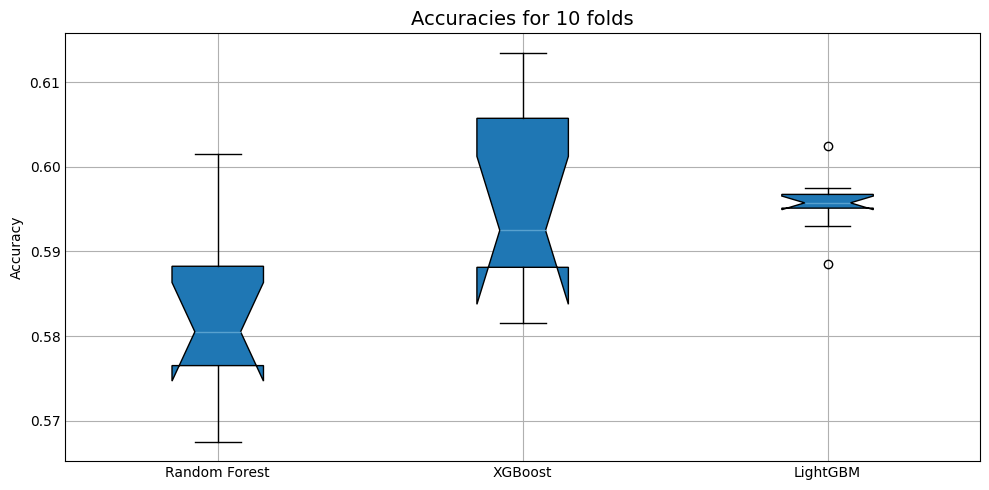

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# --- Validação cruzada ---
scores_rf = cross_val_score(rf, X_proc, y, cv=10, scoring='accuracy')
scores_xgb = cross_val_score(xgb, X_proc, y, cv=10, scoring='accuracy')
scores_lgbm = cross_val_score(lgbm, X_proc, y, cv=10, scoring='accuracy')

# Préparation des données pour le boxplot
accuracies = [scores_rf, scores_xgb, scores_lgbm]
classif_models = ['Random Forest', 'XGBoost', 'LightGBM']
n_runs = len(scores_rf)  # nombre de folds

# Style et affichage
plt.style.use('_mpl-gallery')
fig, axs = plt.subplots(figsize=(10, 5))
axs.boxplot(accuracies, notch=True, labels=classif_models, patch_artist=True)
axs.set_title(f'Accuracies for {n_runs} folds', fontsize=14)
axs.set_ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

O modelo LightGBM é claramente mais eficiente do que os dois outros; é este que vamos buscar otimizar para usá-lo na predição.

## Busca de hiperparâmetros otimizados

- Este código define uma grade de hiperparâmetros para testar (como número de folhas, profundidade máxima, taxa de aprendizado, etc.).

- Depois, utiliza o RandomizedSearchCV para explorar aleatoriamente 50 combinações dessa grade, com uma validação cruzada de 3 dobras, otimizando a acurácia.

- Após a busca, ele exibe os melhores parâmetros encontrados, assim como a melhor média de acurácia obtida durante a validação cruzada.

Esta etapa permite melhorar o desempenho do modelo encontrando a melhor configuração dos hiperparâmetros sem testar exaustivamente todas as combinações.

In [49]:
# Definição do modelo base
lgbm = LGBMClassifier(random_state=42, verbose=-1)

# Grade de parâmetros para testar (exemplo)
param_dist = {
    'num_leaves': [31, 50, 70, 90, 120],
    'max_depth': [7, 10, 15, 20, 25],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 400, 600, 800],
    'min_child_samples': [10, 20, 30, 40],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

# Configuração do RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Iniciar a busca
random_search.fit(X_train, y_train)

# Melhores parâmetros e score
print("Melhores parâmetros:", random_search.best_params_)
print("Melhor acurácia na validação cruzada:", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Melhores parâmetros: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.5, 'num_leaves': 50, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Melhor acurácia na validação cruzada: 0.5948127077589894


## Predição no conjunto de teste e preparação do arquivo de submissão


In [50]:
# --- Treinamento de um modelo com os hiperparâmetros otimizados ---
best_params = {
    'subsample': 0.8,
    'reg_lambda': 1,
    'reg_alpha': 0.5,
    'num_leaves': 50,
    'n_estimators': 800,
    'min_child_samples': 20,
    'max_depth': 10,
    'learning_rate': 0.01,
    'colsample_bytree': 0.7,
    'random_state': 42,
    'verbose': -1
}

final_lgbm = LGBMClassifier(**best_params)
final_lgbm.fit(X_proc, y)

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.01, max_depth=10,
               n_estimators=800, num_leaves=50, random_state=42, reg_alpha=0.5,
               reg_lambda=1, subsample=0.8, verbose=-1)

In [53]:
# --- Predição no conjunto de teste e preparação da submissão ---
y_test_pred = final_lgbm.predict(test_proc)

submission = pd.DataFrame({
    'id_solicitante': test_df['id_solicitante'],
    'inadimplente': y_test_pred
})

submission.to_csv('submission.csv', index=False)
print("Arquivo de submissão salvo: submission.csv")

Arquivo de submissão salvo: submission.csv


## Conclusão / Relatório final

A pontuação final de acurácia que obtive via envio no Kaggle foi: **0,5996**

Durante este projeto, testei uma grande variedade de abordagens para melhorar minha pontuação:

- Criação de novas variáveis (engenharia de features),

- Uso de métodos de ensemble como Stacking e Voting com vários modelos (mas como o LightGBM era claramente superior, incluir o Random Forest e o XGBoost no voto reduzia a pontuação),

- Diversas tentativas de imputação com valores mais frequentes, médias, etc. (a mediana continuou sendo a melhor),

- Tentativas de otimizar os hiperparâmetros com Optuna em vez do RandomizedSearchCV, entre outras estratégias.

No fim, foi com este notebook que consegui obter o melhor resultado:
sem adicionar novas features, utilizando imputadores clássicos e uma abordagem básica de busca de hiperparâmetros.

# Código-fonte completo em uma única célula

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer

train_df = pd.read_csv('data/conjunto_de_treinamento.csv')
test_df = pd.read_csv('data/conjunto_de_teste.csv')
sample_submission = pd.read_csv('data/exemplo_arquivo_respostas.csv')

df_model = train_df.copy()
cat_cols = df_model.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['id_solicitante', 'inadimplente'])
y = df_model['inadimplente']

model = LGBMClassifier(force_row_wise=True, random_state=42, n_estimators=100, learning_rate=0.1)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

limite_importancia = 5
features_a_manter = importances_sorted[importances_sorted >= limite_importancia].index.tolist()

colunas_a_manter_treino = features_a_manter + ['inadimplente', 'id_solicitante']
colunas_a_manter_teste = features_a_manter + ['id_solicitante']

train_df_reduzido = train_df[colunas_a_manter_treino].copy()
test_df_reduzido = test_df[colunas_a_manter_teste].copy()

def preprocess(df, imputers=None, fit_imputers=False):
    df = df.copy()
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    if fit_imputers:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        num_imputer = SimpleImputer(strategy='median')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
        df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
        imputers = {'cat_imputer': cat_imputer, 'num_imputer': num_imputer}
    else:
        df[categorical_cols] = imputers['cat_imputer'].transform(df[categorical_cols])
        df[numeric_cols] = imputers['num_imputer'].transform(df[numeric_cols])

    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    return df, imputers

X = train_df_reduzido.drop(columns=['id_solicitante', 'inadimplente'])
y = train_df_reduzido['inadimplente']

X_processado, imputers = preprocess(X, fit_imputers=True)
test_processado, _ = preprocess(test_df_reduzido.drop(columns=['id_solicitante']), imputers=imputers, fit_imputers=False)

colunas_faltando = set(X_processado.columns) - set(test_processado.columns)
for col in colunas_faltando:
    test_processado[col] = 0
colunas_extras = set(test_processado.columns) - set(X_processado.columns)
test_processado.drop(columns=colunas_extras, inplace=True)
test_processado = test_processado[X_processado.columns]

scaler = StandardScaler()
X_proc = pd.DataFrame(scaler.fit_transform(X_processado), columns=X_processado.columns)
test_proc = pd.DataFrame(scaler.transform(test_processado), columns=test_processado.columns)

X_train, X_val, y_train, y_val = train_test_split(X_proc, y, test_size=0.2, random_state=42)

best_params = {
    'subsample': 0.8,
    'reg_lambda': 1,
    'reg_alpha': 0.5,
    'num_leaves': 50,
    'n_estimators': 800,
    'min_child_samples': 20,
    'max_depth': 10,
    'learning_rate': 0.01,
    'colsample_bytree': 0.7,
    'random_state': 42,
    'verbose': -1
}

final_lgbm = LGBMClassifier(**best_params)
final_lgbm.fit(X_proc, y)

y_test_pred = final_lgbm.predict(test_proc)

submission = pd.DataFrame({
    'id_solicitante': test_df['id_solicitante'],
    'inadimplente': y_test_pred
})

submission.to_csv('submission.csv', index=False)
print("Arquivo de submissão salvo: submission.csv")

[LightGBM] [Info] Number of positive: 10000, number of negative: 10000
[LightGBM] [Info] Total Bins 1544
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Arquivo de submissão salvo: submission.csv
